In [3]:
! pip install  python-dotenv  langgraph langchain-community langchain-openai tavily-python langchain-deepseek langchain-tavily

In [4]:
from langchain_tavily import TavilySearch
from dotenv import load_dotenv
import os
# 加载 .env 文件
load_dotenv()

tools = [TavilySearch(max_results=3,tavily_api_key=os.environ.get('TAVILY_API_KEY'))]

In [7]:
from langchain_deepseek import ChatDeepSeek
from langchain.agents import create_agent

# Choose the LLM that will drive the agent
llm = ChatDeepSeek(
    model="deepseek-v4-flash",
    temperature=0,
    api_key=os.environ["DEEPSEEK_API_KEY"],
    base_url=os.environ["DEEPSEEK_API_BASE"],
)
prompt = "你是一个小助手."
agent_executor = create_agent(llm, tools, system_prompt=prompt)

In [8]:
agent_executor.invoke({"messages": [("user", "谁是2025年最火热的AI Agent项目？")]})

{'messages': [HumanMessage(content='谁是2025年最火热的AI Agent项目？', additional_kwargs={}, response_metadata={}, id='a2e92ef7-f965-4a14-88f9-393fdae16c95'),
  AIMessage(content='好的，我来帮你搜索2025年最火热的AI Agent项目！', additional_kwargs={'refusal': None, 'reasoning_content': '用户想了解2025年最火热的AI Agent项目。我需要搜索相关信息来获取最新的结果。'}, response_metadata={'token_usage': {'completion_tokens': 126, 'prompt_tokens': 1825, 'total_tokens': 1951, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 21, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 1825}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': '447f87a6-602c-43e8-8790-1208408ca0d4', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e8133-7c59-7320-b000-2a19ed75fab1-0', tool_calls=[{'name': 

In [18]:
import operator
from typing import Annotated, List, Tuple
from typing_extensions import TypedDict
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate


llm = ChatDeepSeek(
    model="deepseek-v4-flash",
    temperature=0,
    api_key=os.environ["DEEPSEEK_API_KEY"],
    base_url=os.environ["DEEPSEEK_API_BASE"],
)


class PlanExecute(TypedDict):
    input: str
    plan: List[str]
    past_steps: Annotated[List[Tuple], operator.add]
    response: str



class Plan(BaseModel):
    """未来需要遵循的计划"""

    steps: List[str] = Field(
        description="需要遵循的不同步骤，应该按排序顺序排列"
    )


planner_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """针对给定的目标，制定一个简单的逐步计划。\
该计划应包括单独的任务，如果正确执行这些任务，将得出正确答案。不要添加任何多余的步骤。\
最后一步的结果应该是最终答案。确保每一步都包含所需的所有信息——不要跳过步骤。\
请以 JSON 格式返回，包含 steps 字段（字符串数组）。""",
        ),
        ("placeholder", "{messages}"),
    ]
)
# deepseek-v4-pro/flash 是 thinking 模型，不支持 with_structured_output 默认的 tool_choice
planner = planner_prompt | llm.with_structured_output(Plan, method="json_mode")

In [19]:
planner.invoke(
    {
        "messages": [
            ("user", "中国女子短跑最快的选手是谁？")
        ]
    }
)

Plan(steps=['确定问题：寻找中国女子短跑最快的选手。', '查询中国女子100米纪录，亚洲纪录保持者为李雪梅，成绩10秒79。', '因此，中国女子短跑最快的选手是李雪梅。'])

In [26]:
from typing import Union


class Response(BaseModel):
    """用户的响应。"""

    response: str


class Act(BaseModel):
    """需要执行的操作。"""

    action: Union[Response, Plan] = Field(
        description="需要执行的操作。如果你想直接响应用户，请使用 Response。"
        "如果需要进一步使用工具来获取答案，请使用 Plan。"
    )


replanner_prompt = ChatPromptTemplate.from_template(
    """针对给定的目标，制定一个简单的逐步计划。\
该计划应包括单独的任务，如果正确执行这些任务，将得出正确答案。不要添加任何多余的步骤。\
最后一步的结果应该是最终答案。确保每一步都包含所需的所有信息——不要跳过步骤。

你的目标是：
{input}

你的原始计划是：
{plan}

你目前已完成以下步骤：
{past_steps}

请根据当前情况更新你的计划。如果不需要更多步骤并可以直接响应用户，请返回响应。否则，请补充计划。\
只需添加仍然需要完成的步骤，不要将已经完成的步骤作为计划的一部分返回。\
请以 JSON 格式返回。"""
)


replanner = replanner_prompt | llm.with_structured_output(Act, method="json_mode")

In [27]:
from typing import Literal
from langgraph.graph import END


# 异步函数 execute_step
# 执行计划中的一个步骤。
# 输入参数 state 包含当前计划（plan），函数会格式化计划并执行第一步。
async def execute_step(state: PlanExecute):
    plan = state["plan"]  # 从 state 中获取计划
    # 将计划格式化为字符串，每一步带有序号
    plan_str = "\n".join(f"{i+1}. {step}" for i, step in enumerate(plan))
    task = plan[0]  # 获取计划的第一步任务
    # 格式化提示词，告知代理需要执行计划的第一步
    task_formatted = f"""针对以下计划：
{plan_str}\n\n你的任务是执行第 {1} 步：{task}。"""
    # 调用代理执行器，传递格式化后的任务
    agent_response = await agent_executor.ainvoke(
        {"messages": [("user", task_formatted)]}
    )
    # 返回已完成的步骤，包括任务和代理的响应
    return {
        "past_steps": [(task, agent_response["messages"][-1].content)],
    }


# 异步函数 plan_step
# 根据用户输入生成完整的计划。
async def plan_step(state: PlanExecute):
    # 调用计划生成器，传递用户的输入
    plan = await planner.ainvoke({"messages": [("user", state["input"])]})
    # 返回生成的计划
    return {"plan": plan.steps}


# 异步函数 replan_step
# 根据当前状态重新规划步骤。
async def replan_step(state: PlanExecute):
    # 调用重新规划器，传递当前状态
    output = await replanner.ainvoke(state)
    # 如果输出是用户的响应，则返回响应
    if isinstance(output.action, Response):
        return {"response": output.action.response}
    # 否则返回新的计划
    else:
        return {"plan": output.action.steps}


# 函数 should_end
# 检查是否应该结束任务。
def should_end(state: PlanExecute):
    # 如果状态中存在响应并且响应不为空，则返回 END 表示任务结束
    if "response" in state and state["response"]:
        return END
    # 否则返回 "agent"，表示继续由代理执行任务
    else:
        return "agent"

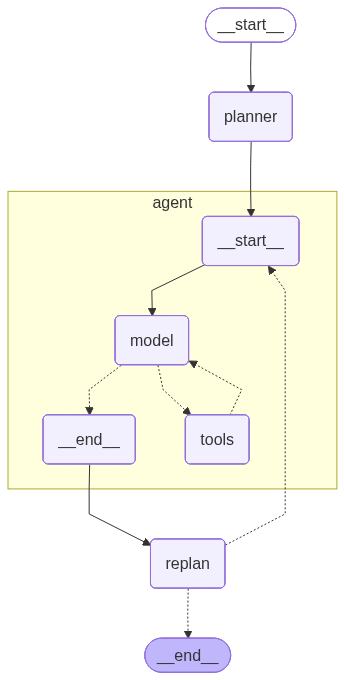

In [28]:
from langgraph.graph import StateGraph, START

# 创建一个状态图，表示工作流
workflow = StateGraph(PlanExecute)

# 添加计划节点
workflow.add_node("planner", plan_step)

# 添加执行步骤节点
workflow.add_node("agent", execute_step)

# 添加重新规划节点
workflow.add_node("replan", replan_step)

# 添加从起点到计划节点的边
workflow.add_edge(START, "planner")

# 从计划节点到执行节点添加边
workflow.add_edge("planner", "agent")

# 从执行节点到重新规划节点添加边
workflow.add_edge("agent", "replan")

# 添加条件边
workflow.add_conditional_edges(
    "replan",
    # 接下来传入一个函数，用于确定下一个节点的调用。
    should_end,
    ["agent", END],  # 根据条件选择继续执行或结束工作流
)

# 最后，编译工作流！
# 这会将状态图编译为一个 LangChain 的 Runnable，
# 意味着你可以像使用其他 Runnable 一样使用它
app = workflow.compile()

from IPython.display import Image, display

display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [29]:
config = {"recursion_limit": 50}
inputs = {"input": "中国女子短跑最快的选手是谁?"}
async for event in app.astream(inputs, config=config):
    for k, v in event.items():
        if k != "__end__":
            print(v)

{'plan': ['确定问题是中国女子短跑最快的选手是谁。', '回忆中国女子短跑历史成绩，李雪梅在1997年全运会上跑出10秒79，是亚洲纪录和全国纪录。', '确认没有其他中国女选手在100米项目上跑出更快成绩。', '得出结论：中国女子短跑最快的选手是李雪梅。']}
{'past_steps': [('确定问题是中国女子短跑最快的选手是谁。', '## 第1步执行完成 ✅\n\n通过搜索确认，问题为：**中国女子短跑最快的选手是谁？**\n\n这是一个关于中国女子100米短跑历史最佳运动员的查询。根据搜索结果显示的关键信息：\n\n- **李雪梅** 以 **10.79秒** 的成绩排名中国女子100米历史第一\n- 她保持着女子100米、200米和4×100米接力三项亚洲纪录\n- 第二名是 **刘晓梅**（10.89秒），第三名是 **韦永丽**（10.99秒）\n\n问题现已明确，可以进行下一步：**回忆中国女子短跑历史成绩，确认李雪梅在1997年全运会上跑出10秒79的成绩。**')]}


OutputParserException: Failed to parse Act from completion {"response": "中国女子短跑最快的选手是李雪梅，她在1997年全运会上跑出10.79秒的亚洲纪录和全国纪录。"}. Got: 1 validation error for Act
action
  Field required [type=missing, input_value={'response': '中国女...录和全国纪录。'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing
For troubleshooting, visit: https://docs.langchain.com/oss/python/langchain/errors/OUTPUT_PARSING_FAILURE 